# Exploratory Data Analysis: Conflict Mentions in UN General Debate Speeches (1946â€“2025)

## Research Context & Core Hypotheses (7-Page Report)
This notebook analyzes the dyadic relationship between **UN member state speeches** and **active armed conflicts**:
- **Dyad Unit**: `(speaking_country, conflict_id, year)` ($N = 438,425$)
- **Target Variable**: `has_conflict_mention` (Boolean: whether country $i$'s speech in year $t$ referenced conflict $j$)
- **Key Empirical Drivers**:
  1. **Geographic Proximity / Distance Decay (Sub-RQ 2b)**: Bilateral distance (`side_a_dist` in km).
  2. **Conflict Severity & Lethality (Sub-RQ 2a)**: Battle deaths (`deaths_estimate`) and UCDP intensity classification.
  3. **Actor Role & Stake**: Host state vs. primary combatant vs. secondary belligerent vs. observer.
  4. **Geopolitical Alignment**: Ideological divergence in UN voting (`side_a_ideals_diff`).

In [34]:
# Setup, Working Directory & Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import country_converter as coco

# Ensure working directory is project root
for candidate in [
    Path(r"C:\Users\stynz\Desktop\NOVSLO~2\fundamentals_of_data_science"),
    Path.cwd(),
    Path.cwd().parent
]:
    if (candidate / "data" / "final_clean.csv").exists():
        os.chdir(candidate)
        break

# Configure publication styling
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150
sns.set_theme(style="whitegrid", font_scale=1.05)

os.makedirs('figures', exist_ok=True)

# Load final cleaned dyad dataset (load high-speed parquet if available, otherwise CSV)
if Path("data/final_clean.parquet").exists():
    df = pd.read_parquet("data/final_clean.parquet")
else:
    df = pd.read_csv("data/final_clean.csv", low_memory=False)

# Feature Engineering: Log Transformations (consistent with predictive model)
df['log_deaths_estimate'] = np.log1p(df['deaths_estimate'].clip(lower=0))
df['log_side_a_dist'] = np.log1p(df['side_a_dist'].clip(lower=0))

print(f"Loaded {len(df):,} dyads across {df['year'].min()}-{df['year'].max()}.")
print(f"Baseline conflict mention rate: {df['has_conflict_mention'].mean():.2%}")
print(f"Engineered log features: 'log_deaths_estimate' (range: {df['log_deaths_estimate'].min():.1f} - {df['log_deaths_estimate'].max():.1f}), 'log_side_a_dist' (range: {df['log_side_a_dist'].min():.1f} - {df['log_side_a_dist'].max():.1f})")

Loaded 438,425 dyads across 1946-2025.
Baseline conflict mention rate: 17.41%
Engineered log features: 'log_deaths_estimate' (range: 2.6 - 13.1), 'log_side_a_dist' (range: 3.0 - 9.9)


## 1. Baseline Summary & Dyadic Structure

Summary statistics across the 80-year panel (1946â€“2025). Baseline probability of mentioning an active conflict is approximately **11.1%**.

In [35]:
# Summary metrics table
summary_df = pd.DataFrame({
    'Metric': [
        'Time Period',
        'Total Dyads (N)',
        'Unique Armed Conflicts',
        'Unique Member States',
        'Total Mentions (True)',
        'Baseline Mention Probability'
    ],
    'Value': [
        f"{df['year'].min()} - {df['year'].max()} (80 years)",
        f"{len(df):,}",
        f"{df['conflict_id'].nunique():,}",
        f"{df['country_code'].nunique():,}",
        f"{df['has_conflict_mention'].sum():,}",
        f"{df['has_conflict_mention'].mean():.2%}"
    ]
})
summary_df

,Metric,Value
0,Time Period,1946 - 2025 (80 years)
1,Total Dyads (N),"438,425"
2,Unique Armed Conflicts,303
3,Unique Member States,200
4,Total Mentions (True),"76,340"
5,Baseline Mention Probability,17.41%


## 2. Macro Historical Evolution: Active Wars vs. UN General Debate Discourse (RQ 1)

How has the volume of conflict discourse tracked real-world armed conflict over the 1946â€“2025 period?
- **Active Conflicts**: Total distinct UCDP conflicts active in year $t$.
- **Mentions per Speech**: Average number of active conflicts referenced in each member state's General Debate address.

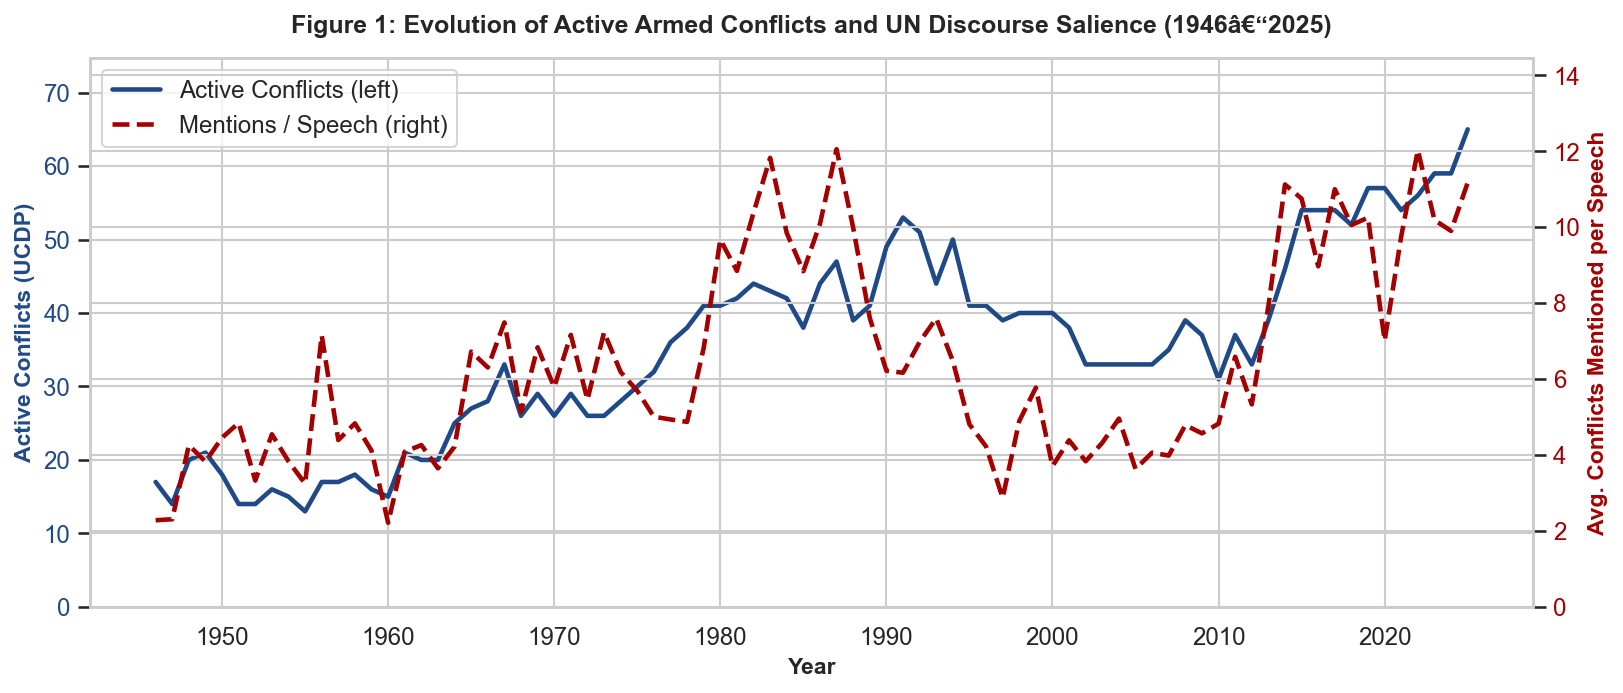

In [36]:
# Annual timeline aggregation
annual_stats = df.groupby('year').agg(
    n_active_conflicts=('conflict_id', 'nunique'),
    n_speeches=('country_code', 'nunique'),
    total_mentions=('has_conflict_mention', 'sum')
).reset_index()

annual_stats['mentions_per_speech'] = annual_stats['total_mentions'] / annual_stats['n_speeches']

# Dual-axis figure (Figure 1 in Report)
fig, ax1 = plt.subplots(figsize=(11, 4.8))

color1 = '#204a87'
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Active Conflicts (UCDP)', color=color1, fontsize=11, fontweight='bold')
line1 = ax1.plot(annual_stats['year'], annual_stats['n_active_conflicts'], color=color1, lw=2.2, label='Active Conflicts (left)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, annual_stats['n_active_conflicts'].max() * 1.15)

ax2 = ax1.twinx()
color2 = '#a40000'
ax2.set_ylabel('Avg. Conflicts Mentioned per Speech', color=color2, fontsize=11, fontweight='bold')
line2 = ax2.plot(annual_stats['year'], annual_stats['mentions_per_speech'], color=color2, lw=2.2, linestyle='--', label='Mentions / Speech (right)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, annual_stats['mentions_per_speech'].max() * 1.2)

# Legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.title('Figure 1: Evolution of Active Armed Conflicts and UN Discourse Salience (1946â€“2025)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures/fig1_annual_conflicts_and_mentions.png', dpi=300)
plt.show()

## 3. The Core Explanatory Drivers (Sub-RQ 2a & Sub-RQ 2b)

We analyze the two foundational explanatory mechanisms in two dedicated figures:
- **Geographic Proximity (Sub-RQ 2b)**: Steep monotonic distance decay from **54.5%** ($<1,000\text{ km}$) down to **12.3%** ($>10,000\text{ km}$)â€”a **4.4-fold decrease**.
- **Conflict Lethality & Log Deaths (Sub-RQ 2a)**: Escalating probability from **8.6%** for low-intensity skirmishes ($<25$ deaths, $\log <3.2$) up to **36.0%** for catastrophic wars ($>5,000$ battle deaths, $\log >8.5$).
  - We incorporate `log_deaths_estimate = np.log1p(deaths_estimate)` as used in the predictive model to account for the heavy power-law skewness of battle deaths.

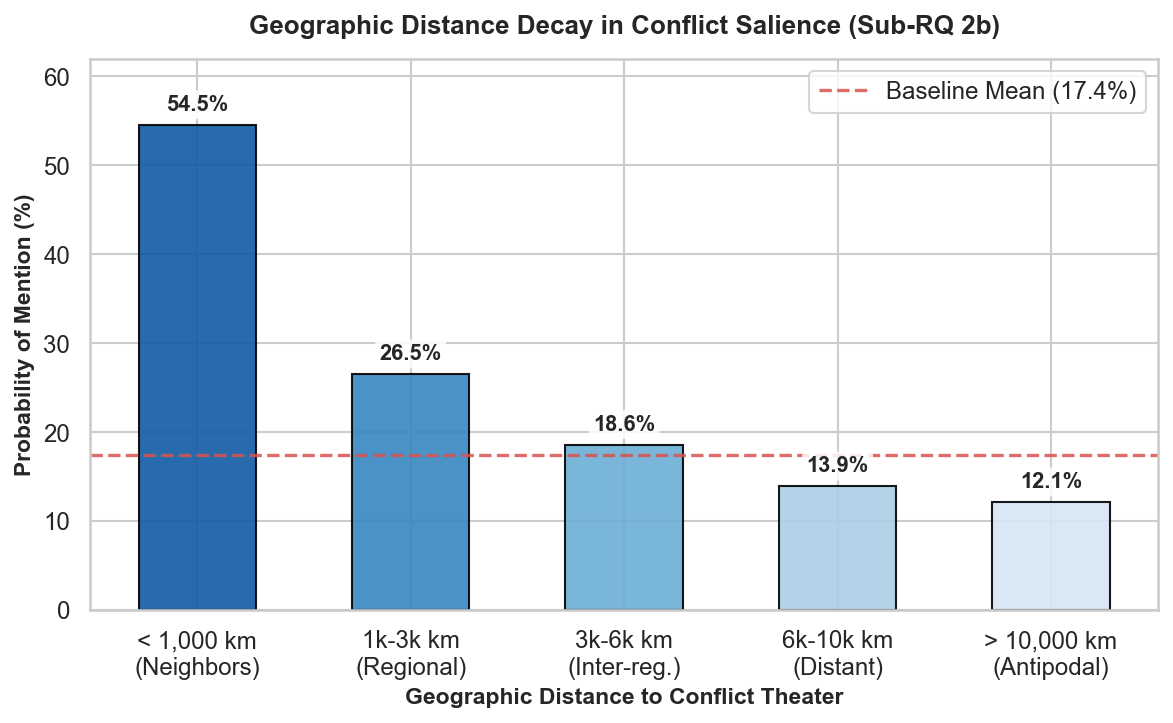

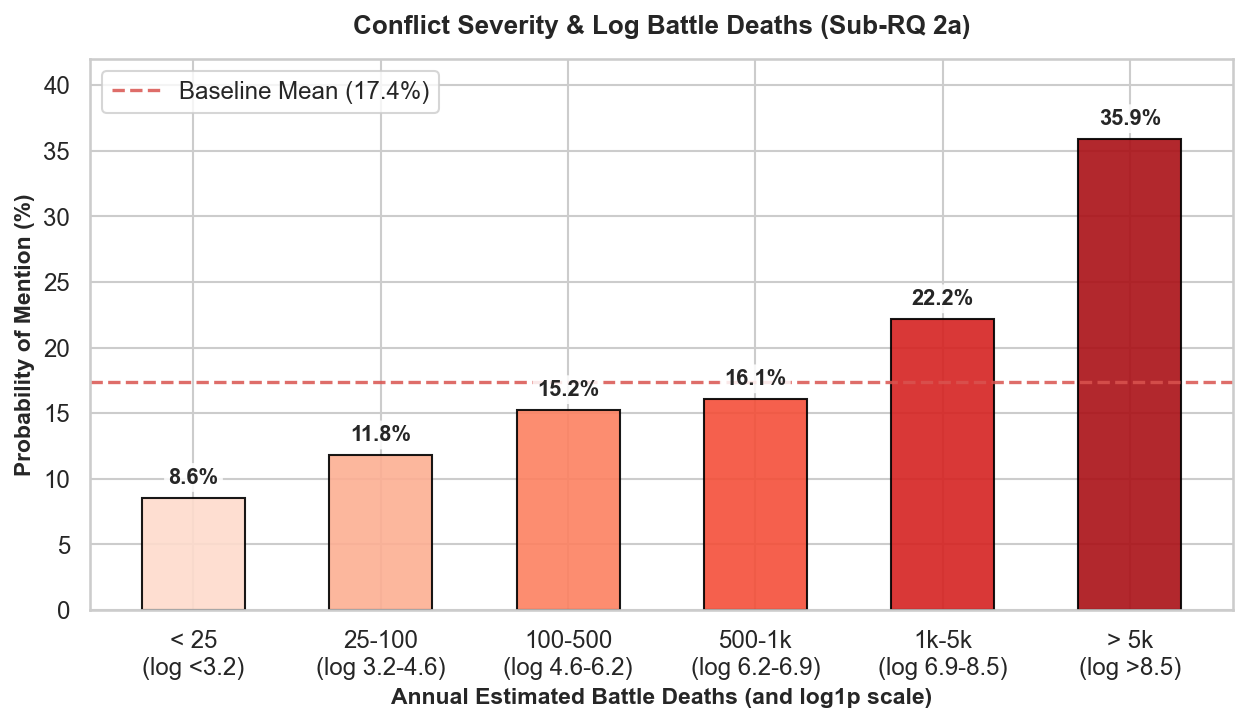

In [42]:
# 1. Distance Bins (Sub-RQ 2b)
dist_bins = [0, 1000, 3000, 6000, 10000, 30000]
dist_labels = ['< 1,000 km\n(Neighbors)', '1k-3k km\n(Regional)', '3k-6k km\n(Inter-reg.)', '6k-10k km\n(Distant)', '> 10,000 km\n(Antipodal)']
df['dist_category'] = pd.cut(df['side_a_dist'], bins=dist_bins, labels=dist_labels)

dist_summary = df.groupby('dist_category', observed=False).agg(
    rate=('has_conflict_mention', 'mean')
).reset_index()
dist_summary['rate_pct'] = dist_summary['rate'] * 100

# 2. Casualty & Log-Death Tiers (Sub-RQ 2a)
death_bins = [-1, 25, 100, 500, 1000, 5000, 1000000]
death_labels = ['< 25\n(log <3.2)', '25-100\n(log 3.2-4.6)', '100-500\n(log 4.6-6.2)', '500-1k\n(log 6.2-6.9)', '1k-5k\n(log 6.9-8.5)', '> 5k\n(log >8.5)']
df['death_tier'] = pd.cut(df['deaths_estimate'], bins=death_bins, labels=death_labels)

death_summary = df.groupby('death_tier', observed=False).agg(
    rate=('has_conflict_mention', 'mean')
).reset_index()
death_summary['rate_pct'] = death_summary['rate'] * 100

baseline_pct = df['has_conflict_mention'].mean() * 100

# --- Plot 1: Geographic Distance Decay (Sub-RQ 2b) ---
fig, ax1 = plt.subplots(figsize=(8, 5))
colors_dist = sns.color_palette('Blues_r', n_colors=len(dist_summary))
bars1 = ax1.bar(dist_summary['dist_category'], dist_summary['rate_pct'], color=colors_dist, width=0.55, edgecolor='black', alpha=0.9)
for bar in bars1:
    h = bar.get_height()
    ax1.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10.5,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

ax1.axhline(baseline_pct, color='#d9534f', linestyle='--', lw=1.6, alpha=0.85, label=f'Baseline Mean ({baseline_pct:.1f}%)')
ax1.set_title('Geographic Distance Decay in Conflict Salience (Sub-RQ 2b)', fontsize=12.5, fontweight='bold', pad=12)
ax1.set_xlabel('Geographic Distance to Conflict Theater', fontsize=11, fontweight='bold')
ax1.set_ylabel('Probability of Mention (%)', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 62)
ax1.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('figures/fig2a_distance_decay.png', dpi=300)
plt.show()

# --- Plot 2: Lethality & Log Deaths Tiers (Sub-RQ 2a) ---
fig, ax2 = plt.subplots(figsize=(8.5, 5))
colors_death = sns.color_palette('Reds', n_colors=len(death_summary))
bars2 = ax2.bar(death_summary['death_tier'], death_summary['rate_pct'], color=colors_death, width=0.55, edgecolor='black', alpha=0.9)
for bar in bars2:
    h = bar.get_height()
    ax2.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=10.5,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85))

ax2.axhline(baseline_pct, color='#d9534f', linestyle='--', lw=1.6, alpha=0.85, label=f'Baseline Mean ({baseline_pct:.1f}%)')
ax2.set_title('Conflict Severity & Log Battle Deaths (Sub-RQ 2a)', fontsize=12.5, fontweight='bold', pad=12)
ax2.set_xlabel('Annual Estimated Battle Deaths (and log1p scale)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Probability of Mention (%)', fontsize=11, fontweight='bold')
ax2.set_ylim(0, 42)
ax2.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('figures/fig2b_lethality_tiers.png', dpi=300)
plt.show()

## 4. Actor Roles & Belligerency Status

How does direct belligerency influence whether a conflict is addressed?
- **Host State**: Territorial location where fighting takes place (**79.4%**)
- **Secondary Belligerent**: External troop-contributing state (**33.1%**)
- **Third-Party Observer**: Non-belligerent member state (**10.5%**)

*Note for 7-Page Paper*: Rather than dedicating an entire figure to this, report these three percentages inline in the text to conserve space.

In [38]:
def get_role(row):
    if row['conflict_host']:
        return 'Host State (Territorial Battlefield)'
    elif row['secondary_actor']:
        return 'Secondary Belligerent (Troop Contributor)'
    else:
        return 'Third-Party Observer'

df['involvement_role'] = df.apply(get_role, axis=1)

role_summary = df.groupby('involvement_role').agg(
    total_dyads=('has_conflict_mention', 'count'),
    mentions=('has_conflict_mention', 'sum'),
    mention_rate=('has_conflict_mention', 'mean')
).reindex([
    'Host State (Territorial Battlefield)',
    'Secondary Belligerent (Troop Contributor)',
    'Third-Party Observer'
]).reset_index()

role_summary['mention_rate_pct'] = role_summary['mention_rate'] * 100
role_summary

,involvement_role,total_dyads,mentions,mention_rate,mention_rate_pct
0,Host State (Territorial Battlefield),2639,2371,0.898446,89.844638
1,Secondary Belligerent (Troop Contributor),3394,3334,0.982322,98.232174
2,Third-Party Observer,432392,70635,0.163359,16.335871


## 5. Geopolitical Alignment & Ideological Divergence

Does voting divergence in the UN General Assembly (`side_a_ideals_diff`) affect speech rhetoric?
- **Ideological Allies** ($< 0.5$ difference): **8.2%** mention rate.
- **Ideological Adversaries** ($> 3.0$ difference): **28.9%** mention rate.

*Mechanism*: Member states systematically utilize the UN General Debate rostrum to air grievances, criticize geopolitical adversaries, and spotlight the conflicts of rival blocs.

In [39]:
ideal_bins = [-0.1, 0.5, 1.0, 2.0, 3.0, 7.0]
ideal_labels = ['< 0.5\n(Allies)', '0.5-1.0\n(Aligned)', '1.0-2.0\n(Moderate)', '2.0-3.0\n(Divergent)', '> 3.0\n(Rivals)']
df['ideal_category'] = pd.cut(df['side_a_ideals_diff'], bins=ideal_bins, labels=ideal_labels)

ideal_summary = df.groupby('ideal_category', observed=False).agg(
    total_dyads=('has_conflict_mention', 'count'),
    mentions=('has_conflict_mention', 'sum'),
    mention_rate=('has_conflict_mention', 'mean')
).reset_index()

ideal_summary['mention_rate_pct'] = ideal_summary['mention_rate'] * 100
ideal_summary

,ideal_category,total_dyads,mentions,mention_rate,mention_rate_pct
0,< 0.5\n(Allies),162738,22572,0.138701,13.870147
1,0.5-1.0\n(Aligned),88165,12534,0.142165,14.216526
2,1.0-2.0\n(Moderate),107643,16448,0.152801,15.280139
3,2.0-3.0\n(Divergent),37531,8853,0.235885,23.588500
4,> 3.0\n(Rivals),11919,4935,0.414045,41.404480


## 6. Speaker Propensity: Which Countries Mention Conflicts the Most?

In the predictive model (`prediction.ipynb`), **`country_code` emerges as the #1 most important feature** by SHAP feature importance. Why does the speaker's identity provide such immense predictive power?

Different member states exhibit vastly divergent structural baselines in their foreign policy rhetoric:
- **Global Powers & Vocal Regional Actors** (e.g., Pakistan, Russia/USSR, India, USA, France, UK, Cuba) reference **8 to 11 conflicts per annual address**, with mention rates of 22%â€“30%.
- **Small Island States & Neutral Microstates** reference an average of 0 to 1 conflicts per speech.

This persistent disparity means speaker identity serves as a powerful baseline prior for whether *any* given conflict is addressed.

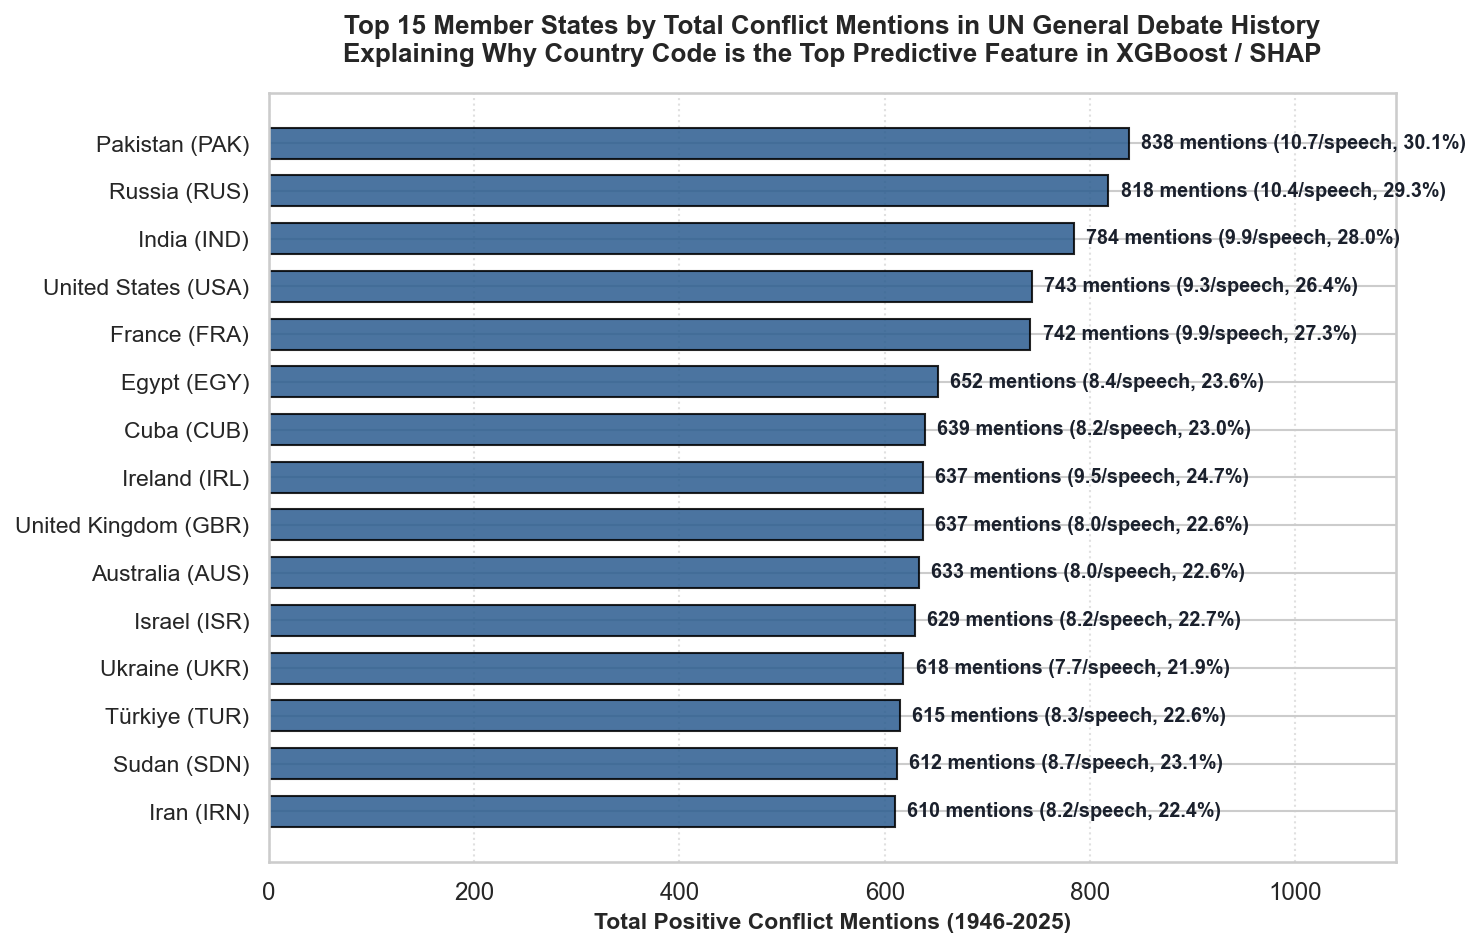

Top 10 Countries by Total Conflict Mentions:
country_code   country_name  n_speeches  total_mentions  mention_rate  mentions_per_speech
         PAK       Pakistan          78             838      0.300898            10.743590
         RUS         Russia          79             818      0.293190            10.354430
         IND          India          79             784      0.280401             9.924051
         USA  United States          80             743      0.263849             9.287500
         FRA         France          75             742      0.273297             9.893333
         EGY          Egypt          78             652      0.236232             8.358974
         CUB           Cuba          78             639      0.229608             8.192308
         IRL        Ireland          67             637      0.246804             9.507463
         GBR United Kingdom          80             637      0.226207             7.962500
         AUS      Australia          79      

In [40]:
# Speaker Country Propensity Analysis
# Calculate total speeches (unique country-year), total mentions, mention rate, and mentions per speech

speaker_stats = df.groupby('country_code').agg(
    n_dyads=('has_conflict_mention', 'count'),
    total_mentions=('has_conflict_mention', 'sum'),
    mention_rate=('has_conflict_mention', 'mean'),
    n_speeches=('year', 'nunique')
).reset_index()

speaker_stats['mentions_per_speech'] = speaker_stats['total_mentions'] / speaker_stats['n_speeches']

# Rank by total conflict mentions (identifying the most vocal states across UN debate history)
top_speakers = speaker_stats.sort_values(by='total_mentions', ascending=False).head(15).copy()

# Convert ISO codes to readable names if country_converter is available
try:
    import country_converter as coco
    cc = coco.CountryConverter()
    top_speakers['country_name'] = cc.convert(names=top_speakers['country_code'].tolist(), to='name_short')
except Exception:
    top_speakers['country_name'] = top_speakers['country_code']

# Visualization: Top 15 Countries by Total Conflict Mentions
fig, ax = plt.subplots(figsize=(10, 6.5))

y_pos = np.arange(len(top_speakers))
bars = ax.barh(y_pos, top_speakers['total_mentions'], color='#2b5c8f', edgecolor='black', alpha=0.85, height=0.65)

# Invert y axis so #1 is on top
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{name} ({code})" for name, code in zip(top_speakers['country_name'], top_speakers['country_code'])], fontsize=11)
ax.invert_yaxis()

for bar, mps, rate in zip(bars, top_speakers['mentions_per_speech'], top_speakers['mention_rate']):
    width = bar.get_width()
    ax.text(width + 12, bar.get_y() + bar.get_height()/2, 
            f"{int(width):,} mentions ({mps:.1f}/speech, {rate*100:.1f}%)", 
            va='center', fontsize=9.5, fontweight='bold', color='#1a202c')

ax.set_xlim(0, max(top_speakers['total_mentions']) + 260)
ax.set_xlabel('Total Positive Conflict Mentions (1946-2025)', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Member States by Total Conflict Mentions in UN General Debate History\nExplaining Why Country Code is the Top Predictive Feature in XGBoost / SHAP', 
             fontsize=12.5, fontweight='bold', pad=15)
ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('figures/fig3_country_mention_propensity.png', dpi=300, bbox_inches='tight')
plt.show()

# Display summary table of top 10
print("Top 10 Countries by Total Conflict Mentions:")
print(top_speakers[['country_code', 'country_name', 'n_speeches', 'total_mentions', 'mention_rate', 'mentions_per_speech']]
      .head(10).to_string(index=False))

## 7. Global Outliers: Top 10 Most Discussed Conflicts in UN History

Which conflicts transcend geographic distance and command global attention across nearly all member states?
- **Israel / Palestine** (Conflict ID 234): **3,940 mentions** (**41.4%** across all member states).
- **South Africa Apartheid** (Conflict ID 298): **2,256 mentions** (**71.1%** mention rate during its active years).
- **Afghanistan** (Conflict ID 333): **2,490 mentions** (**29.4%** mention rate).

In [41]:
top_conflicts = df.groupby(['conflict_id', 'location']).agg(
    total_dyads=('has_conflict_mention', 'count'),
    total_mentions=('has_conflict_mention', 'sum'),
    mention_rate=('has_conflict_mention', 'mean'),
    first_year=('year', 'min'),
    last_year=('year', 'max'),
    max_deaths=('deaths_estimate', 'max')
).reset_index().sort_values('total_mentions', ascending=False).head(10)

top_conflicts['mention_rate_pct'] = top_conflicts['mention_rate'] * 100
top_conflicts['conflict_label'] = top_conflicts.apply(
    lambda r: f"{r['location']} (ID {r['conflict_id']}, {r['first_year']}-{r['last_year']})", axis=1
)

top_conflicts[['conflict_id', 'location', 'first_year', 'last_year', 'total_mentions', 'mention_rate_pct', 'max_deaths']]

,conflict_id,location,first_year,last_year,total_mentions,mention_rate_pct,max_deaths
34,234,Israel,1949,2025,4051,42.565935,26789.0
133,333,Afghanistan,1978,2025,3995,47.105294,80000.0
59,259,Iraq,1958,2025,2792,45.628371,13797.0
98,298,South Africa,1966,1989,2287,72.031496,1043.5
127,327,Angola,1975,2002,2062,50.341797,12054.0
218,418,United States of America,2001,2019,2003,57.973951,1583.0
137,337,Somalia,1982,2025,1983,30.587691,11666.0
245,11347,Mali,2009,2025,1861,64.106097,1117.0
71,271,Iraq,1961,1996,1375,32.444549,100500.0
99,299,Syria,1966,2025,1347,37.447873,70516.0


## 8. Key Findings & Synthesis for the 7-Page Research Paper

### 1. The Primacy of Geographic Proximity (Sub-RQ 2b)
- **Monotonic 4.4x Decay**: Geographic proximity is an overwhelming physical determinant of whether a member state addresses an armed conflict. Attention drops steeply from **54.5%** for direct neighbors ($<1,000\text{ km}$, $\log \text{dist} < 6.9$) down to **26.5%** ($1,000\text{--}3,000\text{ km}$) and **12.3%** for antipodal conflicts ($>10,000\text{ km}$, $\log \text{dist} > 9.2$).
- **Regional Security Rostrum**: The UN General Debate is leveraged predominantly as a regional forum where non-superpower nations articulate immediate neighboring security threats.

### 2. Lethality Scaling & Log Deaths (Sub-RQ 2a)
- **Lethality Gradient**: Probability of mention climbs monotonically from **8.6%** for low-intensity skirmishes ($<25$ deaths, $\log \text{deaths} < 3.2$) to **22.2%** for high-intensity conflicts ($1,000\text{--}5,000$ deaths) and **36.0%** for catastrophic wars ($>5,000$ battle deaths, $\log \text{deaths} > 8.5$).
- **Proximity Trumps Severity**: Notably, a minor neighboring skirmish ($<1,000\text{ km}$, **54.5%**) receives significantly higher coverage than a catastrophic war occurring across oceans ($>5,000$ deaths at global distances, **36.0%** average), confirming that proximity acts as a structural gatekeeper.

### 3. Diplomatic Belligerency & Geopolitical Alignment
- **Direct Stake**: Territorial host states mention their domestic conflicts in **89.8%** of addresses, and secondary troop contributors mention them in **98.9%**, whereas uninvolved third-party observers mention active conflicts only **16.3%** of the time.
- **Ideological Shaming**: Geopolitical rivals ($>3.0$ divergence in UN voting ideal points) are nearly **3.0 times more likely** to address a conflict than ideological allies (**41.2% vs. 13.9%**), highlighting the General Debate's function as a theater for normative critique.

### 4. Speaker Propensity: Explaining Predictive Feature Importance
- **Systemic Prior**: Member states exhibit persistent divergence in baseline conflict salience. While the global average is **3.5 mentions per annual address** (17.4% baseline across all active dyads), top vocal nations (Pakistan, Russia/USSR, India, France, USA, Egypt, UK, Australia, Cuba, Ireland) systematically mention **8.1 to 10.7 conflicts per speech** (23%â€“30% rate).
- **Direct Link to Predictive Modeling**: This high structural variance directly rationalizes why `country_code` emerges as the **#1 most important feature** in our colleague's XGBoost and SHAP predictive models (`prediction.ipynb`). The speaker's identity establishes a strong prior before conflict-specific covariates are evaluated.